In [1]:
# Import needed libraries
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import seaborn as sns

# importing wavelet functions and plotting utilities
from wavelets_wrapper_posh.quick_wavelet import run_full_wavelet_analysis, run_double_wavelet_analysis, unmirror_wavelet_power, unmirror_icwt, unmirror_crosspower, unmirror_coherence, unmirror_phase
from wavelets_wrapper_posh.plot_utils import plot_wavelet_power, plot_coherence, plot_phase

# define fig directory
picture_dir = './figures'

# import the dataframe
data = pd.read_csv('./data/EVI_precip_table_site_12b.csv')
data['Date'] = pd.to_datetime(data['Date'])
print(data.dtypes)
data.head()

Date               datetime64[us]
EVI                       float64
Precipitation             float64
Days_from_Start             int64
dtype: object


,Date,EVI,Precipitation,Days_from_Start
0,2000-02-18,0.4346,158.657083,0
1,2000-03-05,0.3960,94.850713,16
2,2000-03-21,0.3985,127.880925,32
3,2000-04-06,0.3993,93.390097,48
4,2000-04-22,0.3798,125.112214,64


In [2]:
# extract the EVI and precipitation series as arrays
sig_evi = data['EVI'].values
sig_prec = data['Precipitation'].values
days_from_start = data['Days_from_Start'].values

# zero mean the data
sig_prec_zero_mean = sig_prec - np.mean(sig_prec)
sig_evi_zero_mean = sig_evi - np.mean(sig_evi)


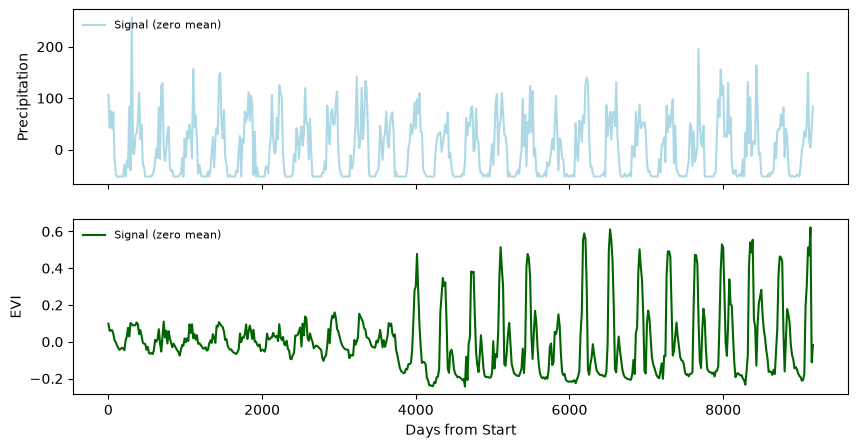

In [3]:
fig, ax = plt.subplots(figsize=(10,5), nrows=2, ncols=1, sharex=True)
# new plot for each signal separately
for i, signal in enumerate([sig_prec_zero_mean, sig_evi_zero_mean]):
    color  = 'lightblue' if np.array_equal(signal, sig_prec_zero_mean) else 'darkgreen'
    ylabel = 'Precipitation' if np.array_equal(signal, sig_prec_zero_mean) else 'EVI'
    ax[i].plot(days_from_start, signal, label='Signal (zero mean)', color=color)
    if i == 0:
        ax[i].set_xlabel('')
    else:
        ax[i].set_xlabel('Days from Start')
    ax[i].set_ylabel(ylabel)
    ax[i].legend(loc='upper left', fontsize=8, frameon=False)

# Wavelet Analysis of Precipitation and EVI

### Parameters and notes

- **Sampling interval:** Precipitation and EVI are sampled every 16 days, so `dt = 16 days`. Note that the value of `dt` affects the magnitude of the calculated wavelet power. For example, using the same signal sampled daily (`dt = 1 day`) versus every 16 days can result in different power values.

- **Zero-mean:** The signal is first demeaned (i.e., its mean is subtracted) before performing the wavelet analysis.

- **Edge effects:** The wavelet code mirrors the signal at both ends to reduce edge effects. This behaviour can be enabled or disabled using the corresponding flag.

- **Wavelet power:** The results include both the standard wavelet power and the rectified wavelet power, following Liu et al. (2007).

  Reference: [Liu et al. (2007)](https://journals.ametsoc.org/view/journals/atot/24/12/2007jtecho511_1.xml)

In [4]:
# run for both signal
_, _, _, _, _, wavelet_power_df_mirrored_EVI, _, _, _, _  = run_full_wavelet_analysis(sig_evi_zero_mean, dt=16, mirror=True, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=2, period_min=365, period_max=730)
_, _, _, _, _, wavelet_power_df_mirrored_prec, _, _, _, _  = run_full_wavelet_analysis(sig_prec_zero_mean, dt=16, mirror=True, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=2, period_min=365, period_max=730)

# unmirror the results
wavelet_power_df_EVI, sumpow_df_EVI = unmirror_wavelet_power(sig_evi_zero_mean, wavelet_power_df_mirrored_EVI,period_min=2, period_max=len(sig_evi_zero_mean)*16-16)
wavelet_power_df_prec, sumpow_df_prec = unmirror_wavelet_power(sig_prec_zero_mean, wavelet_power_df_mirrored_prec,period_min=2, period_max=len(sig_prec_zero_mean)*16-16)

# store in a disctionary for easier access
wavelet_results = {
    "EVI": {
        "wavelet_power": wavelet_power_df_EVI,
        "time-averaged": sumpow_df_EVI
    },
    "Precipitation": {
        "wavelet_power": wavelet_power_df_prec,
        "time-averaged": sumpow_df_prec
    }
}

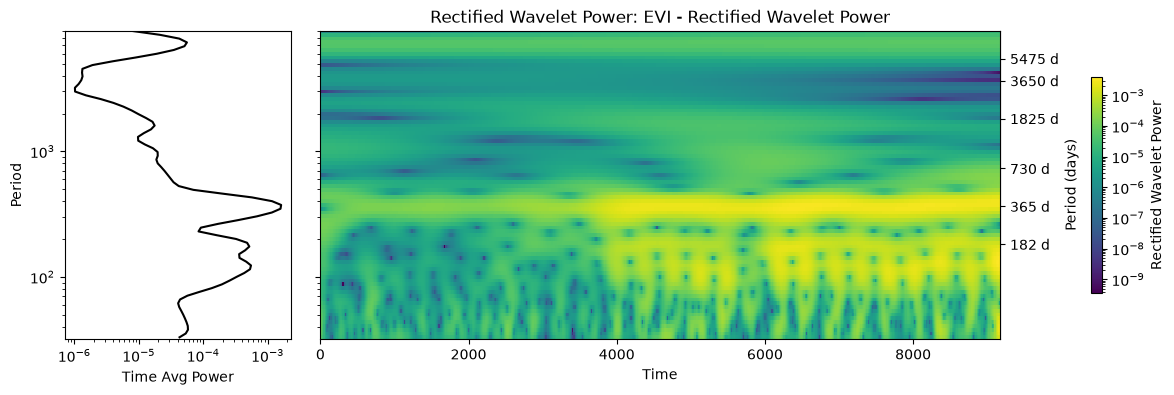

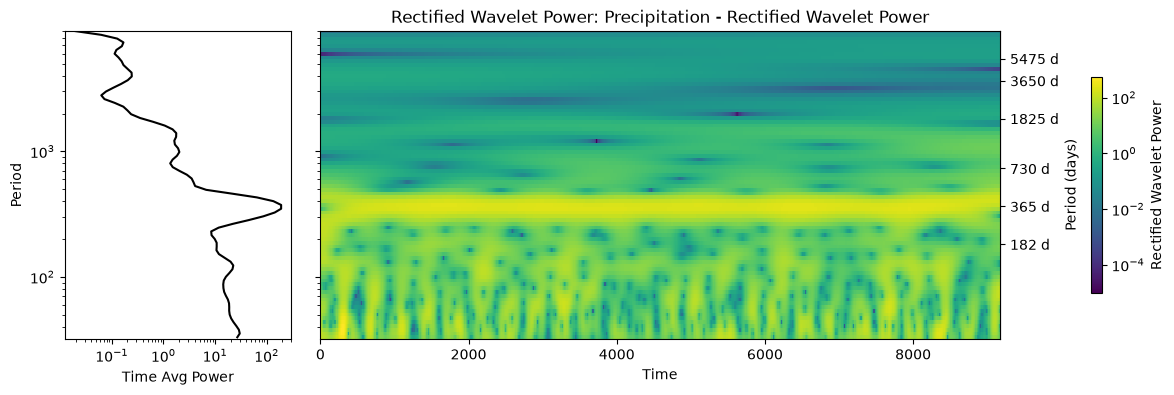

In [5]:
# plot the wavelet power for each signal
for i, signal in enumerate(['EVI', 'Precipitation']):
    plot_wavelet_power(wavelet_results[signal]['wavelet_power'], power_type = "wavelet_power", title = "Rectified Wavelet Power: " + signal, directory = picture_dir)


Both signals show a clear yearly band. The precipitation spectrum appears quite consistent, with not much change over time, while the EVI spectrum shows a marked increase in the yearly band, associated with an increase in the six-month band. This is a site that, from other sources, we know has been affected by land-use change, moving from tree cover to cropland. The shift in the spectrum is consistent with this change.

## Coherence, Crosspower and Phase

Now we will calculate the coherence and crosspower (sometimes also called cross-wavelet) between the two series.

The crosspower describes how the two series vary together at different frequencies and times. It provides information about the strength of their shared variability and can be used to identify frequencies where the two signals have similar patterns.

While the coherence measures the strength of the relationship between the two series at each frequency and time. It ranges from 0 to 1, where values close to 0 indicate a weak relationship and values close to 1 indicate a strong relationship (you can think of it as a correlation in the time-frequency domain).

In [6]:
# run coherence, crosspower and phase
_, _, _, _, _, _, _, _, _, _, _, _, xypower_df, phasexy_df, R2ns_df, _, _, _ = run_double_wavelet_analysis(
            sig_prec_zero_mean, sig_evi_zero_mean,
            dt=16, mirror=True, wf='morlet',
            dj=0.1, om0=6, normmean=True,
            mirrormethod=2, period_min=5, period_max=20,
        )

# unmirror the results
xypower, xysumpow = unmirror_crosspower(
            sig_prec_zero_mean, xypower_df,
            period_min=32, period_max=len(sig_prec_zero_mean)*16-16,
        )
phasexy = unmirror_phase(
            sig_prec_zero_mean, phasexy_df,
            period_min=32, period_max=len(sig_prec_zero_mean)*16-16,
        )
R2ns, R2ns_sumpow = unmirror_coherence(
            sig_prec_zero_mean, R2ns_df,
            period_min=32, period_max=len(sig_prec_zero_mean)*16-16,
        )



Calculating coherence with pycwt...



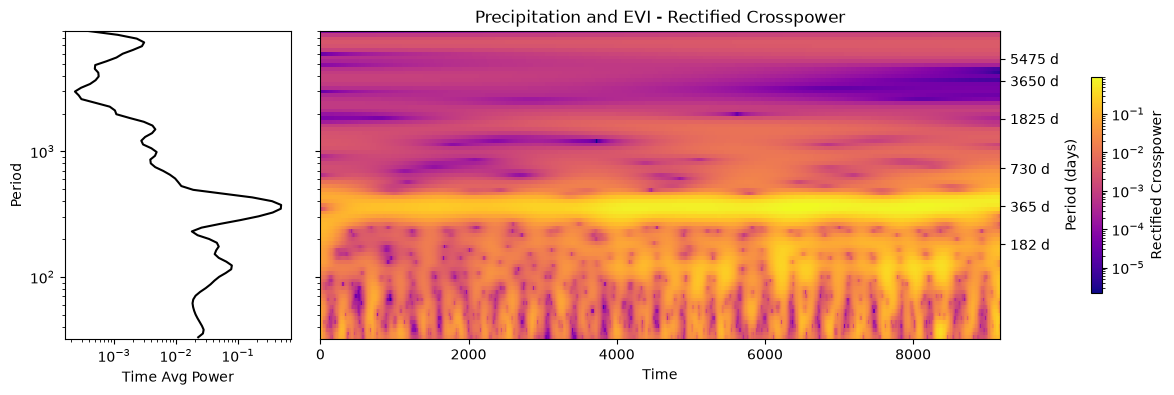

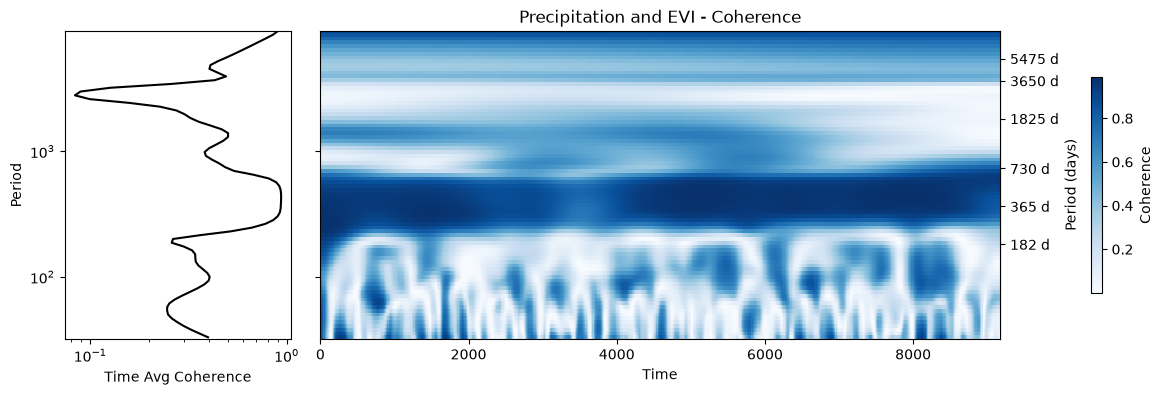

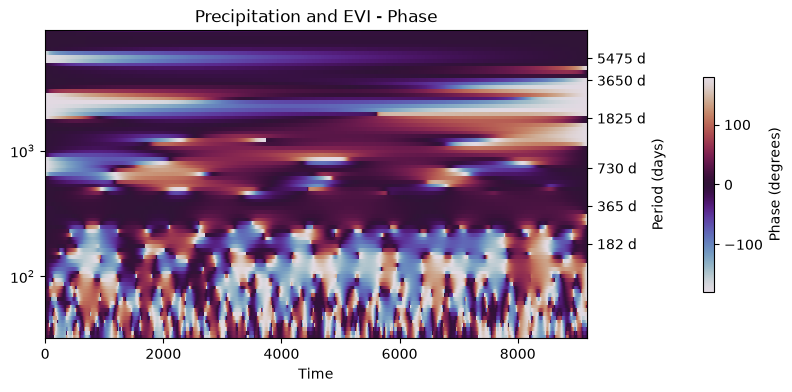

In [7]:
# plot the crosspower
plot_wavelet_power(xypower, power_type = "crosspower", title = "Precipitation and EVI", directory = picture_dir)

# plot coherence
plot_coherence(R2ns, title = "Precipitation and EVI", directory = picture_dir)

# plot the phase
plot_phase(phasexy, title = "Precipitation and EVI", directory = picture_dir)